### BARRION, Mary Barbie
### DE GUZMAN, Adrian Gil

# CSCI 118.03 Image Classification Lab

This lab uses a subset (2,000 images) of Google's Dogs vs. Cats dataset from Kaggle (originally 25,000 images) to:

- Train a convolutional neural network (CNN) for image classification  
- Customize the CNN architecture  

The dataset is downloaded and extracted locally in `/tmp` for efficient training and experimentation.  

In [1]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /tmp/cats_and_dogs_filtered.zip

--2025-05-25 12:44:20--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.68.207, 64.233.170.207, 142.251.175.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.68.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M  20.4MB/s    in 3.9s    

2025-05-25 12:44:25 (16.9 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [2]:
import os
import zipfile

local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [3]:
base_dir = '/tmp/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Directory with our training cat pictures
train_cats_dir = os.path.join(train_dir, 'cats')

# Directory with our training dog pictures
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Directory with our validation cat pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')

# Directory with our validation dog pictures
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

Now, let's see what the filenames look like in the `cats` and `dogs` `train` directories (file naming conventions are the same in the `validation` directory):

In [4]:
train_cat_fnames = os.listdir(train_cats_dir)
print(train_cat_fnames[:10])

train_dog_fnames = os.listdir(train_dogs_dir)
train_dog_fnames.sort()
print(train_dog_fnames[:10])

['cat.847.jpg', 'cat.225.jpg', 'cat.519.jpg', 'cat.158.jpg', 'cat.843.jpg', 'cat.943.jpg', 'cat.219.jpg', 'cat.700.jpg', 'cat.90.jpg', 'cat.426.jpg']
['dog.0.jpg', 'dog.1.jpg', 'dog.10.jpg', 'dog.100.jpg', 'dog.101.jpg', 'dog.102.jpg', 'dog.103.jpg', 'dog.104.jpg', 'dog.105.jpg', 'dog.106.jpg']


Let's find out the total number of cat and dog images in the `train` and `validation` directories:

In [5]:
print('total training cat images:', len(os.listdir(train_cats_dir)))
print('total training dog images:', len(os.listdir(train_dogs_dir)))
print('total validation cat images:', len(os.listdir(validation_cats_dir)))
print('total validation dog images:', len(os.listdir(validation_dogs_dir)))

total training cat images: 1000
total training dog images: 1000
total validation cat images: 500
total validation dog images: 500


For both cats and dogs, we have 1,000 training images and 500 test images.

Now let's take a look at a few pictures to get a better sense of what the cat and dog datasets look like. First, configure the matplot parameters:

In [ ]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [6]:
%matplotlib inline

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

Now, display a batch of 8 cat and 8 dog pictures. You can rerun the cell to see a fresh batch each time:

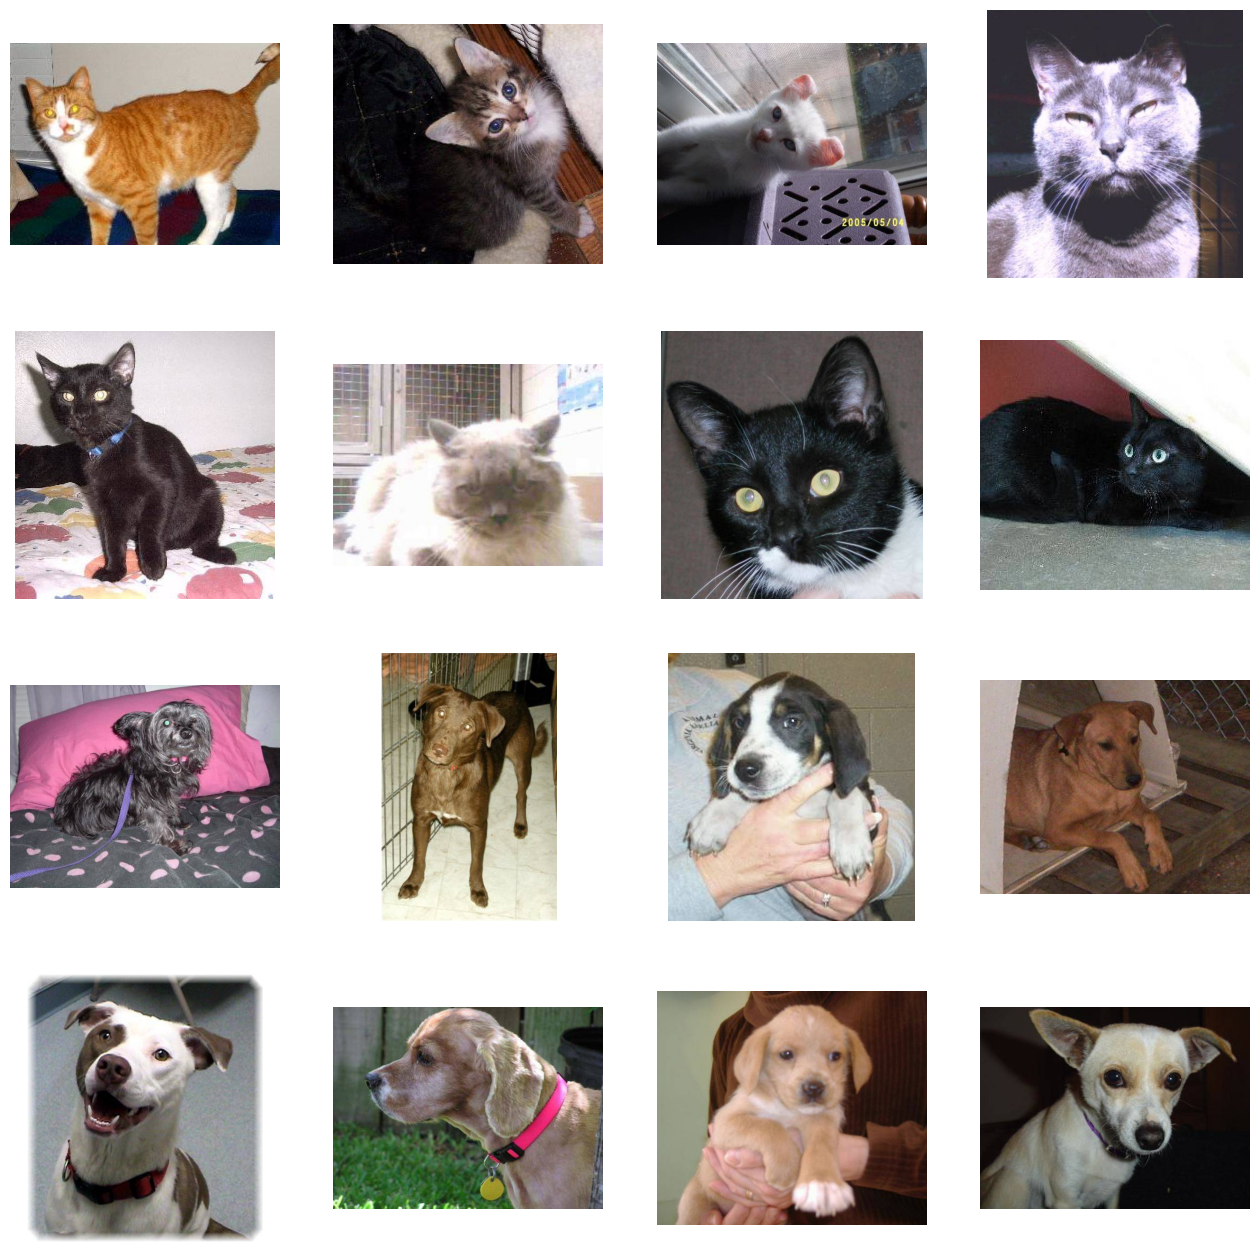

In [7]:
# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8
next_cat_pix = [os.path.join(train_cats_dir, fname)
                for fname in train_cat_fnames[pic_index-8:pic_index]]
next_dog_pix = [os.path.join(train_dogs_dir, fname)
                for fname in train_dog_fnames[pic_index-8:pic_index]]

for i, img_path in enumerate(next_cat_pix+next_dog_pix):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()


## Building CNN based Neural Network

These are the imports for the libraries necessary for our models.

In [8]:
# Install required libraries
# !pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.image as mpimg
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# seed value
seed = 12

# Set fixed seed
torch.manual_seed(seed)

In [9]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# Define transforms for data preprocessing
train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),  # Resize images to 150x150
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

validation_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

### CNN 2 Conv Layers

In [11]:
class CNNv2(nn.Module):
    def __init__(self):
        super(CNNv2, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.conv5 = nn.Conv2d(512, 1024, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(1024)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Initialize fully connected layers
        self._initialize_fc()

    def _initialize_fc(self):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, 150, 150)
            dummy_output = self.pool(torch.relu(self.bn1(self.conv1(dummy_input))))
            dummy_output = self.pool(torch.relu(self.bn2(self.conv2(dummy_output))))
            dummy_output = self.pool(torch.relu(self.bn3(self.conv3(dummy_output))))
            dummy_output = self.pool(torch.relu(self.bn4(self.conv4(dummy_output))))
            dummy_output = self.pool(torch.relu(self.bn5(self.conv5(dummy_output))))
            flattened_size = dummy_output.view(-1).shape[0]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = self.pool(torch.relu(self.bn5(self.conv5(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def name(self):
        return "CNNv2"

### Setting hyperparameters

In [12]:
# Set model
model = CNNv2().to(device)

# Define hyperparameters
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
batch_size = 32
epochs = 100

# Load datasets
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
validation_data = datasets.ImageFolder(validation_dir, transform=validation_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, worker_init_fn=np.random.seed(seed))
validation_loader = DataLoader(validation_data, batch_size=32, shuffle=False, worker_init_fn=np.random.seed(seed))

# Get a batch from train_loader and get shape
image, _ = next(iter(train_loader))
print(f"Image shape: {image.shape}")

model

Image shape: torch.Size([32, 3, 150, 150])


CNNv2(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_feat

### Training and Evaluating the model

Model: CNNv2



Epoch 1, Loss: 0.979262


Epoch 2, Loss: 0.736729


Epoch 3, Loss: 0.665791


Epoch 4, Loss: 0.637118


...

Epoch 96, Loss: 0.061632


Epoch 97, Loss: 0.009256


Epoch 98, Loss: 0.032182


Epoch 99, Loss: 0.020663


Epoch 100, Loss: 0.032988
Execution time: 18.74 minutes
Avg time per epoch: 0.19 minutes



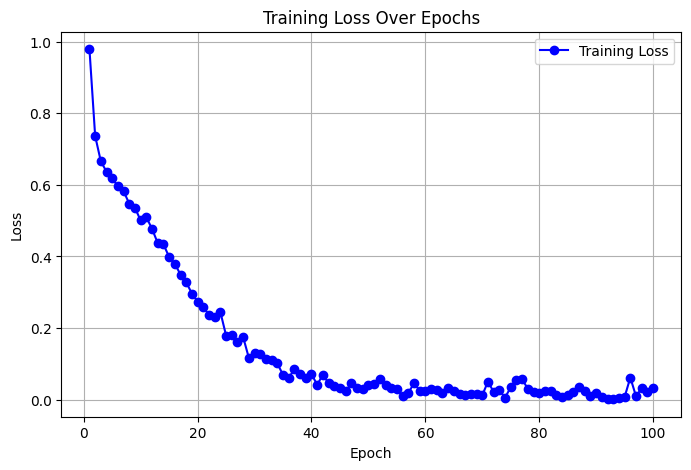


Validation Accuracy: 85.30%


In [13]:
import time

start_time = time.perf_counter()
loss_values = []

print(f"Model: {model.name()}\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    loss_values.append(running_loss/len(train_loader))

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.6f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {(execution_time)/60:.2f} minutes")
print(f"Avg time per epoch: {((execution_time/epochs)/60):.2f} minutes")

# Plot the loss graph
print()
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_values, marker='o', linestyle='-', color='b', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(validation_loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'\nValidation Accuracy: {100 * correct / total:.2f}%')

In [14]:
# Save model weights only
torch.save(model.state_dict(), 'cnn_model_weights.pth')

# Save the entire model
torch.save(model, 'cnn_model_full.pth')

Validation Accuracy: 88.30%

# Plot Classification Results on Images

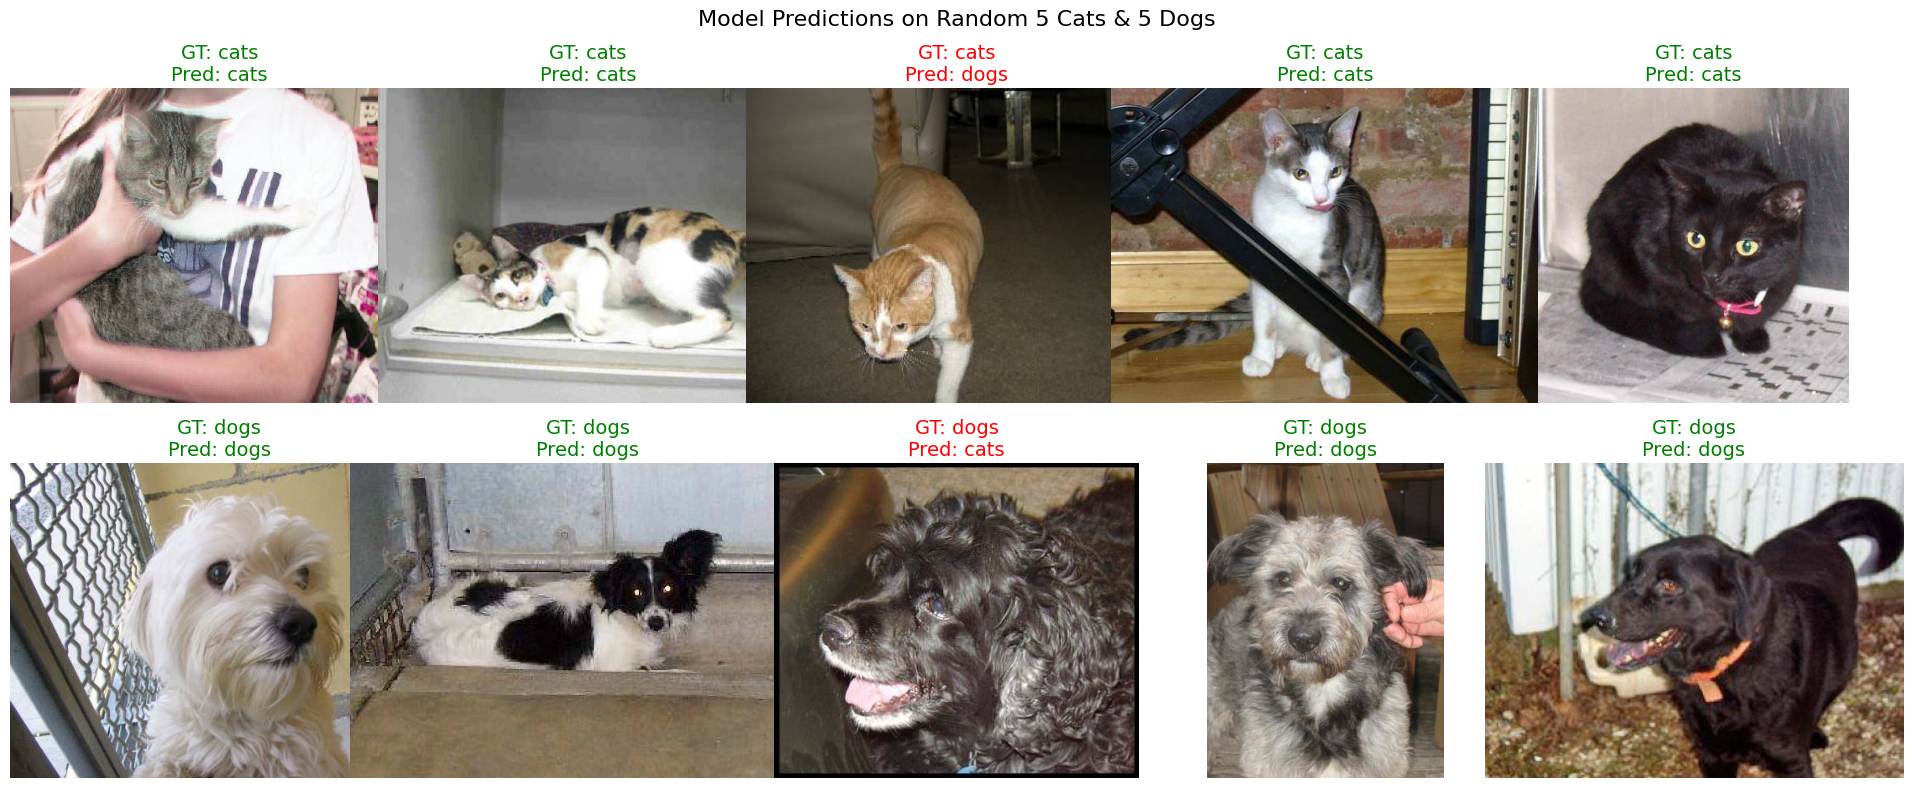

In [193]:
# Re-initialize model and load saved weights
model = CNNv2().to(device)
model.load_state_dict(torch.load('cnn_model_weights.pth'))
model.eval()

# Class labels
class_names = train_data.classes  # ['cats', 'dogs']

# Helper: Predict class from image tensor
def predict_image(img_tensor):
    img_tensor = img_tensor.unsqueeze(0).to(device)  # add batch dimension
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
    return predicted.item()

# Select 5 random images from cats and 5 from dogs
sample_cat_files = random.sample(os.listdir(validation_cats_dir), 5)
sample_dog_files = random.sample(os.listdir(validation_dogs_dir), 5)

sample_paths = [(os.path.join(validation_cats_dir, fname), 0) for fname in sample_cat_files] + \
               [(os.path.join(validation_dogs_dir, fname), 1) for fname in sample_dog_files]

# Plot predictions
plt.figure(figsize=(20, 8))

for i, (img_path, true_label) in enumerate(sample_paths):
    # Load and preprocess image
    image = mpimg.imread(img_path)
    img = Image.open(img_path).convert('RGB')
    img_tensor = validation_transforms(img)

    pred_label = predict_image(img_tensor)

    plt.subplot(2, 5, i+1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(
      f"GT: {class_names[true_label]}\nPred: {class_names[pred_label]}",
      color='green' if pred_label == true_label else 'red',
      fontsize=14
    )


plt.suptitle("Model Predictions on Random 5 Cats & 5 Dogs", fontsize=16)
plt.subplots_adjust(hspace=5)
plt.tight_layout()
plt.show()

# Plot Grad-CAM  Results on Images

In [22]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 98.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.4 MB/s

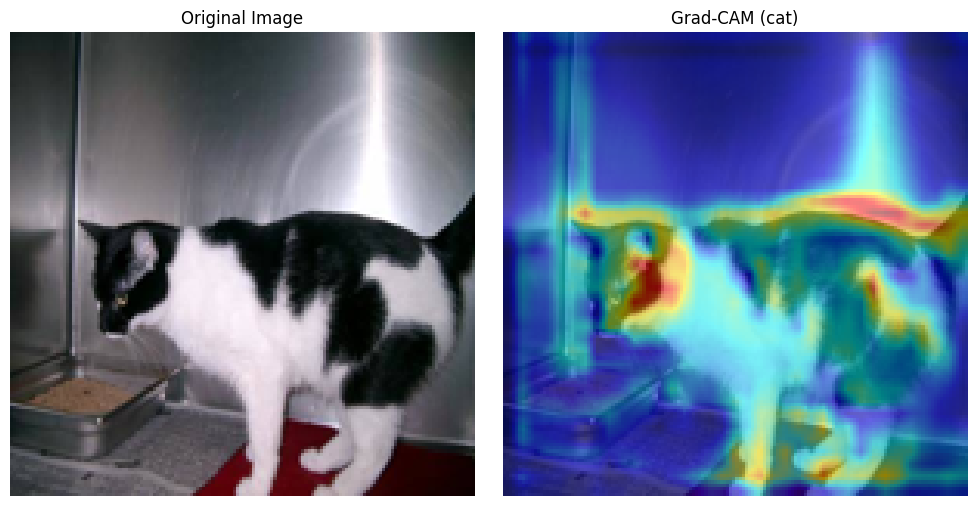

In [218]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# load the model again
model = CNNv2().to(device)
model.load_state_dict(torch.load("cnn_model_weights.pth"))
model.eval()

# get list of cat and dog images
val_cats = os.listdir(validation_cats_dir)
val_dogs = os.listdir(validation_dogs_dir)

# randomly pick either a cat or dog image
cls = random.choice(["cats", "dogs"])
if cls == "cats":
    path = os.path.join(validation_cats_dir, random.choice(val_cats))
    label = 0
else:
    path = os.path.join(validation_dogs_dir, random.choice(val_dogs))
    label = 1

# open the image and turn it into a tensor
img = Image.open(path).convert("RGB")
img_tensor = validation_transforms(img).unsqueeze(0).to(device)

# resize and normalize it so we can visualize later
img_np = np.array(img.resize((150, 150))).astype(np.float32) / 255.0

# set up grad-cam with the layer we wanna look at
target_layer = model.conv3
cam = GradCAM(model=model, target_layers=[target_layer])

# focus the cam on the actual label (cat or dog)
target_category = [ClassifierOutputTarget(label)]
grayscale_cam = cam(input_tensor=img_tensor, targets=target_category)[0]

# apply the heatmap on top of the image
cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# plot both the original and the cam image side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM ({'cat' if label == 0 else 'dog'})")
plt.axis("off")

plt.tight_layout()
plt.show()

## Show grad-cam on interesting images

In [137]:
selected_cat_files = ['cat.2348.jpg', 'cat.2200.jpg', 'cat.2069.jpg', 'cat.2104.jpg', 'cat.2395.jpg']
selected_dog_files = ['dog.2077.jpg', 'dog.2219.jpg', 'dog.2430.jpg', 'dog.2289.jpg', 'dog.2423.jpg']

# cat: 2196, 2128 - background only
# dog: 2186, 2445 - leash

custom_samples = [(os.path.join(validation_cats_dir, f), 0) for f in selected_cat_files] + \
                 [(os.path.join(validation_dogs_dir, f), 1) for f in selected_dog_files]


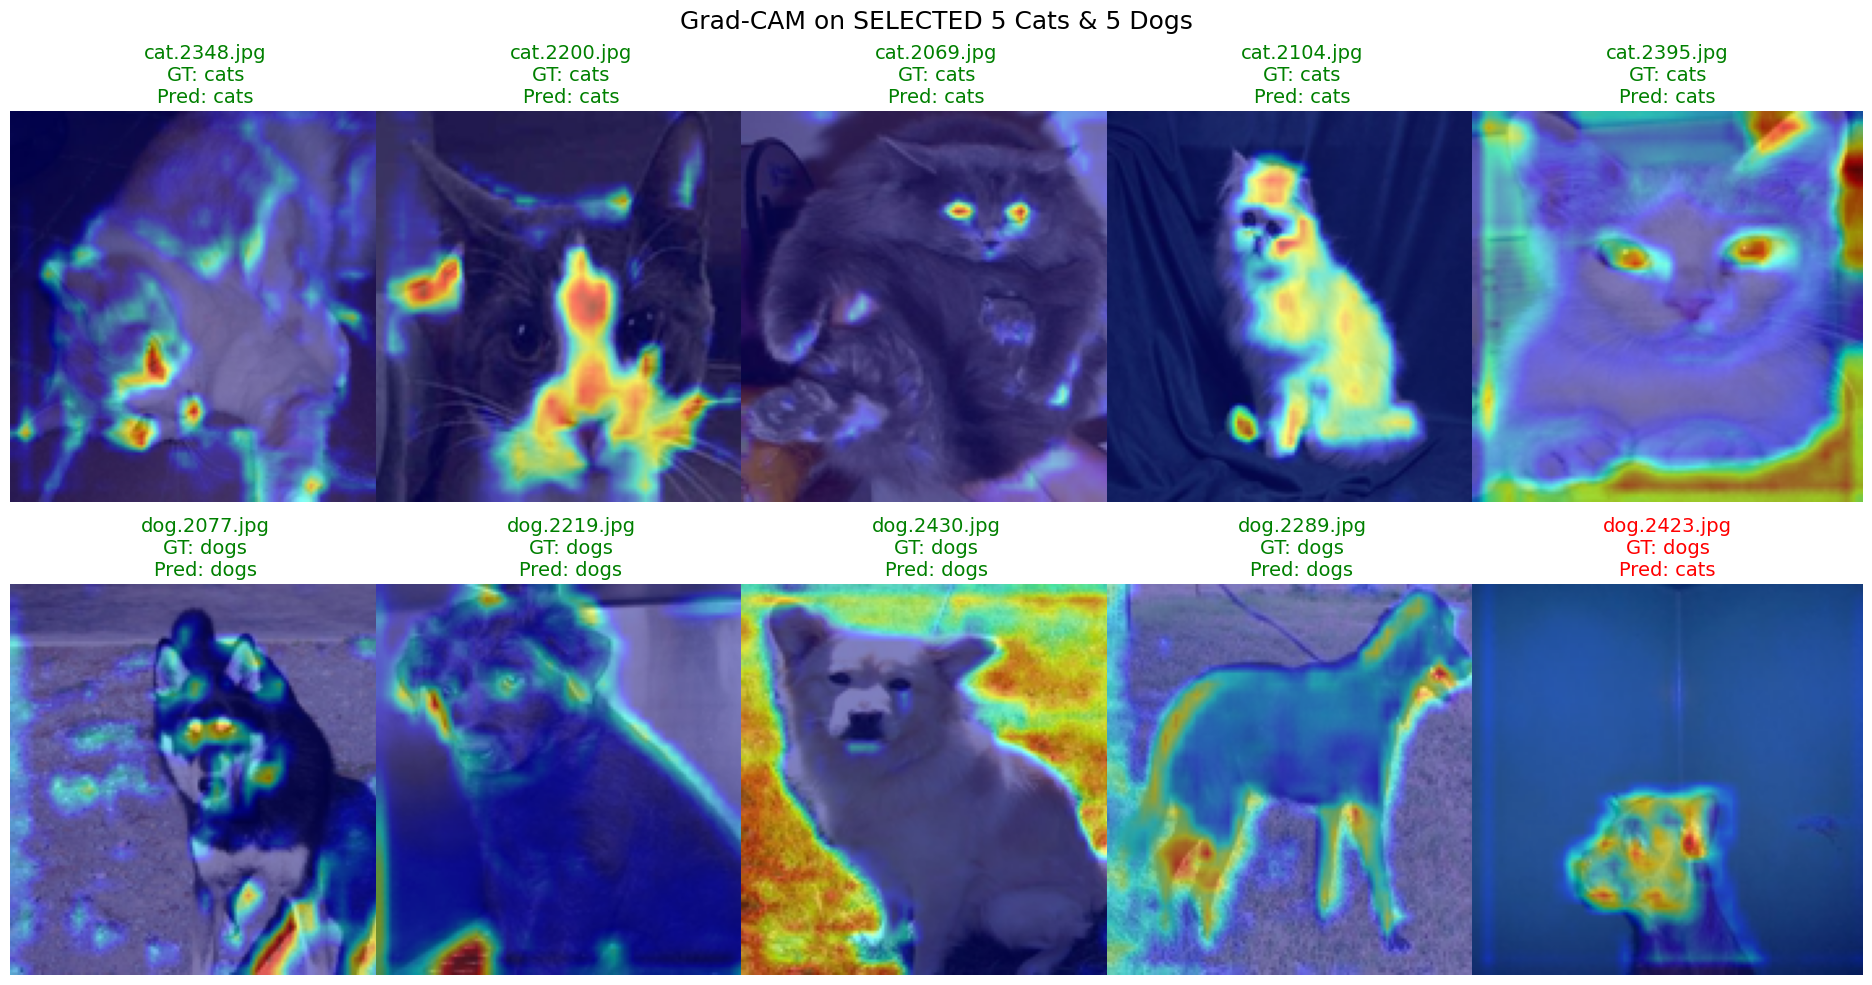

In [196]:
plt.figure(figsize=(20, 10))

for i, (img_path, true_label) in enumerate(custom_samples):
    # open image and turn into a tensor
    img = Image.open(img_path).convert('RGB')
    img_tensor = validation_transforms(img)
    pred_label = predict_image(img_tensor)

    # resize and normalize for cam overlay
    img_np = np.array(img.resize((150, 150))).astype(np.float32) / 255.0
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # set up cam to focus on predicted class
    target_category = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=target_category)[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # plot
    plt.subplot(2, 5, i+1)
    plt.imshow(cam_image)
    plt.axis('off')
    fname = os.path.basename(img_path)

    # set the title color based on if prediction is correct
    title_color = 'green' if pred_label == true_label else 'red'
    plt.title(f"{fname}\nGT: {class_names[true_label]}\nPred: {class_names[pred_label]}",
              color=title_color, fontsize=14)

plt.suptitle("Grad-CAM on SELECTED 5 Cats & 5 Dogs", fontsize=18)
plt.subplots_adjust(hspace=5)
plt.tight_layout()
plt.show()


##  Show grad-cam on random images

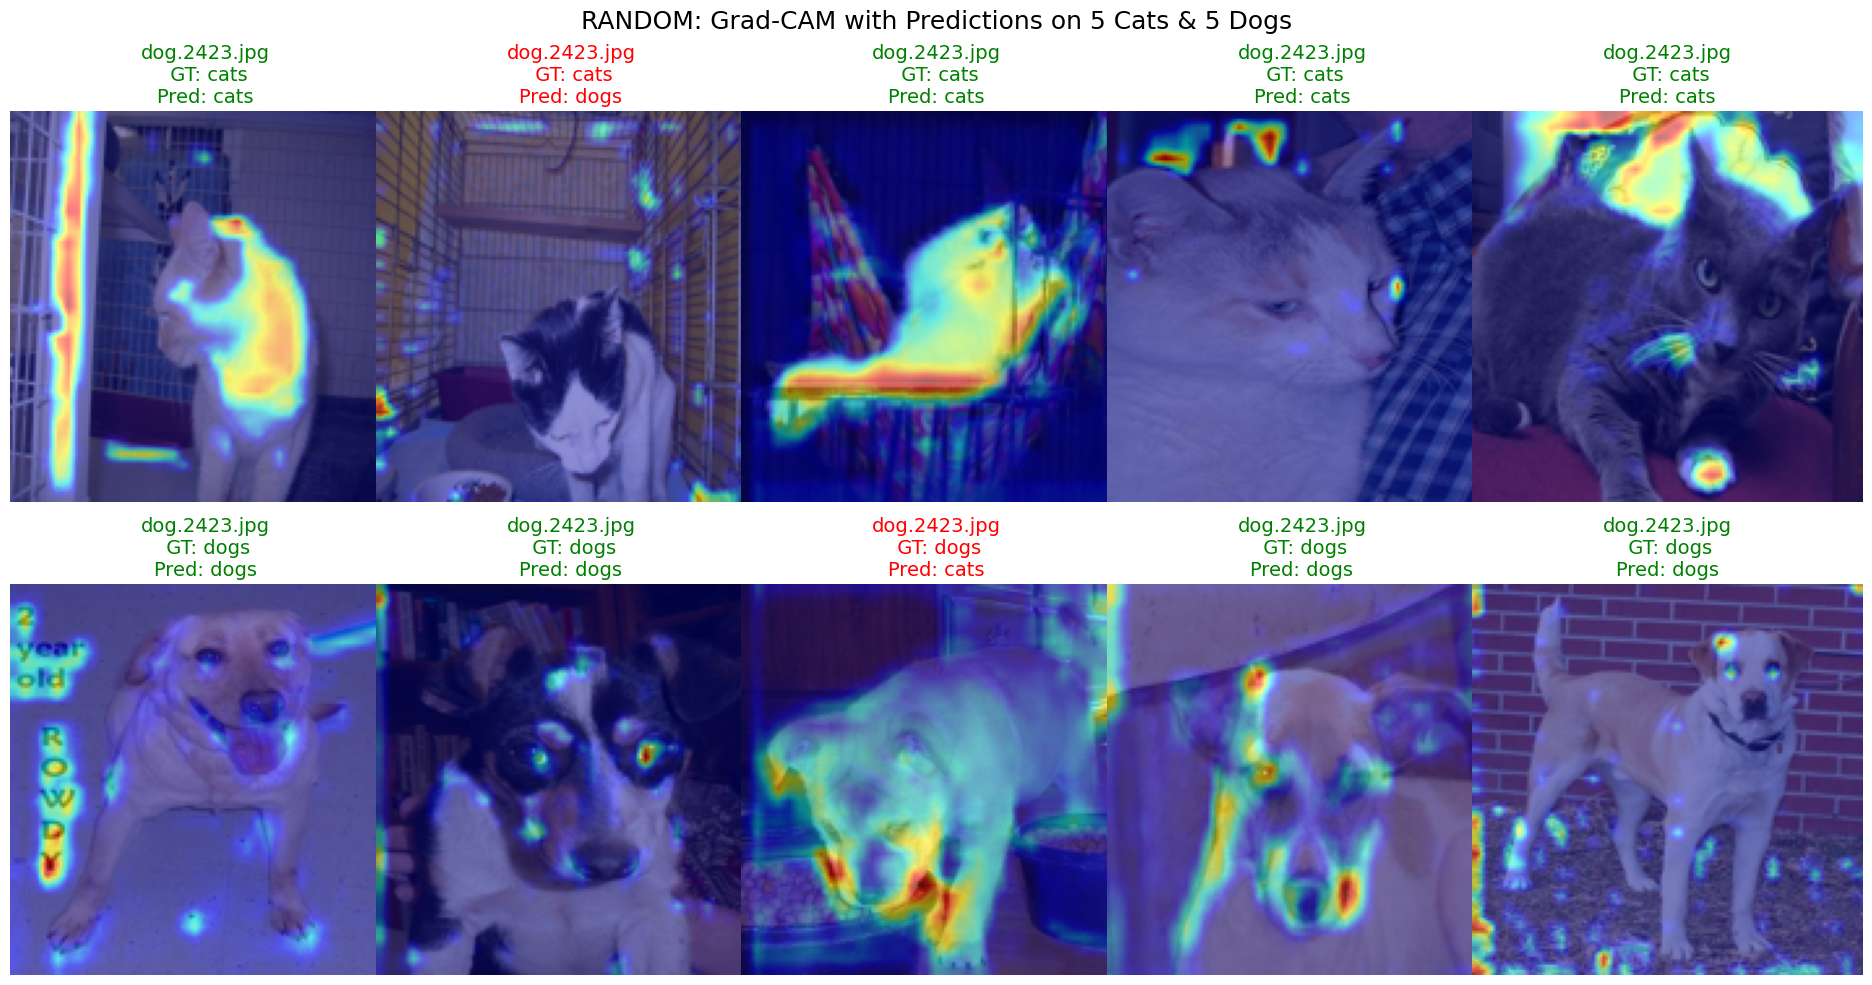

In [188]:
# load model again
model = CNNv2().to(device)
model.load_state_dict(torch.load('cnn_model_weights.pth'))
model.eval()

# helper function to predict class
def predict_image(img_tensor):
    img_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
    return predicted.item()

# pick 5 random cats and 5 random dogs
sample_cats = random.sample(os.listdir(validation_cats_dir), 5)
sample_dogs = random.sample(os.listdir(validation_dogs_dir), 5)
samples = [(os.path.join(validation_cats_dir, f), 0) for f in sample_cats] + \
          [(os.path.join(validation_dogs_dir, f), 1) for f in sample_dogs]

# set the layer we want grad-cam to focus on
target_layer = model.conv3
cam = GradCAM(model=model, target_layers=[target_layer])

plt.figure(figsize=(20, 10))
for i, (img_path, true_label) in enumerate(samples):
    img = Image.open(img_path).convert('RGB')
    img_tensor = validation_transforms(img)
    pred_label = predict_image(img_tensor)

    img_np = np.array(img.resize((150, 150))).astype(np.float32) / 255.0
    input_tensor = img_tensor.unsqueeze(0).to(device)

    target_category = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=target_category)[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.subplot(2, 5, i+1)
    plt.imshow(cam_image)
    plt.axis('off')
    title_color = 'green' if pred_label == true_label else 'red'
    plt.title(f"{fname}\n GT: {class_names[true_label]}\nPred: {class_names[pred_label]}",
              color=title_color, fontsize=14)

plt.suptitle("RANDOM: Grad-CAM with Predictions on 5 Cats & 5 Dogs", fontsize=18)
plt.subplots_adjust(hspace=5)
plt.tight_layout()
plt.show()